In [5]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [7]:
import os

print("This notebook is currently running from this folder:")
print(os.getcwd())

print("\nCan Python find the data file?")
print(os.path.exists("time_series_60min_singleindex.csv"))

This notebook is currently running from this folder:
c:\Users\annak\Desktop\dtu

Can Python find the data file?
True


## DATA LOAD & PREPROCESSING

In [8]:
file_path = 'time_series_60min_singleindex.csv'

countries = ["CZ", "DE", "AT", "PL"]

target_columns = ["utc_timestamp"]
for c in countries:
    target_columns += [
        f"{c}_load_actual_entsoe_transparency",
        f"{c}_solar_generation_actual",
        f"{c}_wind_onshore_generation_actual"
    ]

df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

df_2019 = df.loc['2019-01-01':'2019-12-31'].copy().ffill().bfill().fillna(0)

# --- TECH DATA ---
def annuity(n, r):
    if r > 0:        
        return r / (1 - 1/(1+r)**n)
    else:
        return 1 / n

discount_rate = 0.07

# Gas marginal cost calculation
# Source: #https://www.sciencedirect.com/science/article/abs/pii/S036054421831288X?fr=RR-2&ref=pdf_download&rr=9ea337d92f634f62
fuel_cost_gas = 21.6 
vom_gas = 3.0        
gas_marginal = (fuel_cost_gas / 0.39) + vom_gas # 0.39 from gas efficiency

# Costs and parameters for each technology
# Source: #https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf
tech_data = {
    'solar':       {'inv': 750000,  'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#f1c40f"},
    'wind':        {'inv': 1240000, 'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#3498db"},
    'nuclear':     {'inv': 6000000, 'fom': 0.025,'life': 40, 'marg': 11.5,          'eff': 1.00, 'avail': 0.9,              'color': "#e74c3c"},
    'coal':        {'inv': 1300000, 'fom': 0.02, 'life': 40, 'marg': 51.0,          'eff': 1.00, 'avail': 1.0, 'co2': 0.34, 'color': "#7f8c8d"},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'marg': gas_marginal,  'eff': 0.39, 'avail': 1.0, 'co2': 0.19, 'color': "#e67e22"}
} # should we change eff?

# Installed capacities of solar and wind of each country for CF scaling
# Source: #https://transparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222019%22%2C%222019%22%5D%2C%22tz%22%3A%22CET%22%7D
installed = {
    "CZ": {"solar": 2049,   "wind": 316},
    "DE": {"solar": 45435,  "wind": 52946},
    "PL": {"solar": 430,    "wind": 5808},
    "AT": {"solar": 1193,   "wind": 3035},
} 

# Capacity factors of solar and wind of each country
for c in countries:
    df_2019[f"{c}_solar_cf"] = (
        df_2019[f"{c}_solar_generation_actual"] / installed[c]["solar"]
    ).clip(0, 1)

    df_2019[f"{c}_wind_cf"] = (
        df_2019[f"{c}_wind_onshore_generation_actual"] / installed[c]["wind"]
    ).clip(0, 1)

## NETWORK

In [11]:
# --- NETWORK MODEL ---
n = pypsa.Network()
n.set_snapshots(df_2019.index)

# Buses
n.add("Bus", countries)

# Gas buses
for c in countries:
    n.add("Bus", f"{c}_gas")

# Carriers
for tech, d in tech_data.items():
    n.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

n.add("Carrier", "ch4", co2_emissions=0.19, color="#e67e22")

# --- LOADS ---
for c in countries:
    n.add("Load", f"{c}_load",
          bus=c,
          p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        if tech == "gas":
            continue  # Gas will be added as a separate generator on DE gas bus

        name = f"{c}_{tech}"

        # Costs
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        # Marginal cost + CF
        if  tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]
            efficiency = d["eff"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]
            efficiency = d["eff"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]
            efficiency = d["eff"]

        n.add("Generator",
              name,
              bus = c,
              carrier = tech,
              p_nom_extendable = True,
              capital_cost = capital_cost,
              marginal_cost = marginal_cost,
              efficiency = efficiency,
              p_max_pu = p_max_pu)

# Gas supply for DE gas bus        
n.add("Generator", "DE_gas_supply",
      bus = "DE_gas",
      carrier = "ch4",
      p_nom_extendable = True,
      marginal_cost = fuel_cost_gas)

# n.add("Generator", "PL_gas_supply",
#       bus = "PL_gas",
#       carrier = "ch4",
#       p_nom_extendable = True,
#       marginal_cost = fuel_cost_gas)

# n.add("Generator", "CZ_gas_supply",
#       bus = "CZ_gas",
#       carrier = "ch4",
#       p_nom_extendable = True,
#       marginal_cost = fuel_cost_gas)

# n.add("Generator", "AT_gas_supply",
#       bus = "AT_gas",
#       carrier = "ch4",
#       p_nom_extendable = True,
#       marginal_cost = fuel_cost_gas)

# --- TRANSMISSION ---
# Capacities based on 2026 max physical flows between the countries
# Source: #https://transparency.entsoe.eu/transmission/physicalFlows?appState=%7B%22sa%22%3A%5B%22CTY%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22CTY%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%222026-04-01%22%2C%22tz%22%3A%22CET%22%7D
lines = [
    ("CZ", "DE", 3500), # max: 3449
    ("CZ", "AT", 2500), # max: 2390
    ("CZ", "PL", 2500), # max: 2487
    ("DE", "PL", 3000), # max: 2820
]

# Add electrical lines
for b0, b1, cap in lines:
    n.add("Line", f"{b0}-{b1}", 
          bus0=b0, 
          bus1=b1, 
          x=1, 
          s_nom=cap)

# Add gas pipelines
for b0, b1, cap in lines:
    n.add("Link", f"{b0}-{b1}_gas_pipe",
          bus0=f"{b0}_gas",
          bus1=f"{b1}_gas",
          p_nom_extendable=True,
          efficiency=1)

# Add gas-to-power conversion links    
for c in countries:
    n.add("Link", f"{c}_gas_to_power",
          bus0=f"{c}_gas",
          bus1=c,
          efficiency=0.39,
          p_nom_extendable=True,
          capital_cost=tech_data["gas"]["inv"] * (annuity(30, discount_rate) + 0.04),
          marginal_cost=0) # Marginal cost is 0 because fuel cost is accounted in the gas supply generator

# --- CO2 CONSTRAINT ---
# n.add("GlobalConstraint", "co2_limit",
#       type="primary_energy",
#       carrier_attribute="co2_emissions",
#       sense="<=",
#       constant=10e6)

# --- Fix pandas / PyPSA string dtype compatibility issue ---
for component_df in [
    n.buses,
    n.carriers,
    n.generators,
    n.loads,
    n.lines,
    n.links,
    n.storage_units,
]:
    component_df.index = component_df.index.astype(str).astype(object)

    for col in component_df.columns:
        if component_df[col].dtype == "string":
            component_df[col] = component_df[col].astype(object)

# --- OPTIMIZATION ---
status, condition = n.optimize(solver_name="highs")

print("Status:", status)
print("Condition:", condition)

Index(['CZ', 'DE', 'AT', 'PL', 'CZ_gas', 'DE_gas', 'AT_gas', 'PL_gas'], dtype='object', name='name')
Index(['CZ-DE_gas_pipe', 'CZ-AT_gas_pipe', 'CZ-PL_gas_pipe', 'DE-PL_gas_pipe',
       'CZ_gas_to_power', 'DE_gas_to_power', 'AT_gas_to_power',
       'PL_gas_to_power'],
      dtype='object', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='object', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 124.21it/s]
INFO:linopy.io: Writing time: 0.61s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 254065 primals, 586945 duals
Objective: 5.54e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-uppe

Status: ok
Condition: optimal


Part H - Baseline CO2 emissions

In [12]:
#Calculate baseline CO2 emissions


def calculate_system_emissions(n):
    """
    Calculates total system-wide CO2 emissions.

    The formula uses:
    - generator dispatch over time,
    - generator efficiency,
    - carrier-specific CO2 emissions,
    - snapshot weightings to annualize the result.
    """

    emissions = (
        n.generators_t.p
        .div(n.generators.efficiency, axis=1)
        .mul(n.generators.carrier.map(n.carriers.co2_emissions), axis=1)
        .mul(n.snapshot_weightings.generators, axis=0)
        .sum()
        .sum()
    )

    return emissions


baseline_emissions = calculate_system_emissions(n)

print(f"Baseline system-wide CO2 emissions: {baseline_emissions / 1e6:.2f} MtCO2/year")

Baseline system-wide CO2 emissions: 258.00 MtCO2/year


Part H - Selected CO2 target and constrained optimisation

In [ ]:
# PART H - Select decarbonisation target

# We select one decarbonisation target:
# 50% of the baseline system-wide CO2 emissions
target_fraction = 0.50

co2_limit = baseline_emissions * target_fraction

print(f"Selected decarbonisation target: {target_fraction*100:.0f}% of baseline emissions")
print(f"CO2 allowance limit: {co2_limit / 1e6:.2f} MtCO2/year")

Selected decarbonisation target: 50% of baseline emissions
CO2 allowance limit: 129.00 MtCO2/year


In [15]:
# PART H - Add global CO2 constraint and re-optimise

# PyPSA keeps an internal solver model after optimisation.
# Before copying a solved network, we remove the attached solver model.
try:
    n.model.solver_model = None
except AttributeError:
    pass

# Create a copy of the baseline interconnected network.
# This keeps the original baseline results unchanged.
n_h = n.copy()

# Add the global CO2 constraint.
# The system is not allowed to emit more than the selected CO2 limit.
n_h.add(
    "GlobalConstraint",
    "co2_limit_part_h",
    type="primary_energy",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=co2_limit
)

# Fix pandas / PyPSA string dtype compatibility issue before solving again
for component_df in [
    n_h.buses,
    n_h.carriers,
    n_h.generators,
    n_h.loads,
    n_h.lines,
    n_h.links,
    n_h.storage_units,
]:
    component_df.index = component_df.index.astype(str).astype(object)

    for col in component_df.columns:
        if component_df[col].dtype == "string":
            component_df[col] = component_df[col].astype(object)

# Re-optimise the system under the CO2 constraint
status_h, condition_h = n_h.optimize(solver_name="highs")

print("Status:", status_h)
print("Condition:", condition_h)

Index(['CZ', 'DE', 'AT', 'PL', 'CZ_gas', 'DE_gas', 'AT_gas', 'PL_gas'], dtype='object', name='name')
Index(['CZ-DE_gas_pipe', 'CZ-AT_gas_pipe', 'CZ-PL_gas_pipe', 'DE-PL_gas_pipe',
       'CZ_gas_to_power', 'DE_gas_to_power', 'AT_gas_to_power',
       'PL_gas_to_power'],
      dtype='object', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='object', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='object', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 134.58it/s]
INFO:linopy.io: Writing time: 0.66s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 254065 primals, 586946 duals
Objective: 6.15e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-u

Status: ok
Condition: optimal


## Part H  CO2 price

In [16]:
#Extract the model-implied CO2 price

# Calculate the actual emissions after applying the CO2 constraint
actual_emissions_h = calculate_system_emissions(n_h)

# Extract the shadow price of the global CO2 constraint
raw_co2_shadow_price = n_h.global_constraints.loc["co2_limit_part_h", "mu"]

# The sign can be negative because of the mathematical convention of <= constraints.
# For reporting, we use the positive value as the CO2 price.
co2_price = abs(raw_co2_shadow_price)

print(f"Baseline emissions: {baseline_emissions / 1e6:.2f} MtCO2/year")
print(f"Selected CO2 limit: {co2_limit / 1e6:.2f} MtCO2/year")
print(f"Actual emissions after optimisation: {actual_emissions_h / 1e6:.2f} MtCO2/year")
print(f"Raw shadow price: {raw_co2_shadow_price:.2f}")
print(f"Model-implied CO2 price: {co2_price:.2f} EUR/tCO2")

Baseline emissions: 258.00 MtCO2/year
Selected CO2 limit: 129.00 MtCO2/year
Actual emissions after optimisation: 129.00 MtCO2/year
Raw shadow price: -67.18
Model-implied CO2 price: 67.18 EUR/tCO2


## Single Gas Bus (DE)

In [ ]:
# --- NETWORK MODEL ---
n2 = pypsa.Network()
n2.set_snapshots(df_2019.index)

# Electricity buses
n2.add("Bus", countries)

# SINGLE gas bus
n2.add("Bus", "DE_gas")

# Carriers
for tech, d in tech_data.items():
    n2.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

n2.add("Carrier", "ch4", co2_emissions=0.19, color="#e67e22")

# --- LOADS ---
for c in countries:
    n2.add("Load", f"{c}_load",
           bus=c,
           p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        if tech == "gas":
            continue

        name = f"{c}_{tech}"
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        if tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]

        n2.add("Generator",
               name,
               bus=c,
               carrier=tech,
               p_nom_extendable=True,
               capital_cost=capital_cost,
               marginal_cost=marginal_cost,
               efficiency=d["eff"],
               p_max_pu=p_max_pu)

# --- GAS SUPPLY ---
n2.add("Generator", "DE_gas_supply",
       bus="DE_gas",
       carrier="ch4",
       p_nom_extendable=True,
       marginal_cost=fuel_cost_gas)

# --- ELECTRICITY TRANSMISSION ---
lines = [
    ("CZ", "DE", 3500),
    ("CZ", "AT", 2500),
    ("CZ", "PL", 2500),
    ("DE", "PL", 3000),
]

for b0, b1, cap in lines:
    n2.add("Line", f"{b0}-{b1}",
           bus0=b0,
           bus1=b1,
           x=1,
           s_nom=cap)

# --- GAS TO POWER ---
for c in countries:
    n2.add("Link", f"{c}_gas_to_power",
           bus0="DE_gas",
           bus1=c,
           efficiency=0.39,
           p_nom_extendable=True,
           capital_cost=tech_data["gas"]["inv"] *
                        (annuity(tech_data["gas"]["life"], discount_rate) + tech_data["gas"]["fom"]),
           marginal_cost=0)

# --- OPTIMIZATION ---
n2.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_52864\3263682582.py:89: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL', 'DE_gas'], dtype='str', name='name')
Index(['CZ_gas_to_power', 'DE_gas_to_power', 'AT_gas_to_power',
       'PL_gas_to_power'],
      dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 80.64it/s]
INFO:linopy.io: Writing time: 1.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 167237 iterations and 8.27 seconds (5.01 work units)


INFO:gurobipy:Solved in 167237 iterations and 8.27 seconds (5.01 work units)


Optimal objective  5.536271382e+10


INFO:gurobipy:Optimal objective  5.536271382e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219021 primals, 490581 duals
Objective: 5.54e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')

## OUTPUT

In [ ]:
# print(f"\nTotal System Cost: {n.objective/1e6:.2f} M€")

# print("\nCapacities:")
# print(n.generators.p_nom_opt)

# # --- 10. METRICS ---
# print("\n--- SYSTEM METRICS ---")

# total_demand = n.loads_t.p_set.sum().sum()
# total_gen = n.generators_t.p.sum().sum()

# print(f"Total Demand: {total_demand/1e6:.2f} TWh")
# print(f"Total Generation: {total_gen/1e6:.2f} TWh")

# # CO2
# co2 = 0
# for g in n.generators.index:
#     carrier = n.generators.at[g, "carrier"]
#     co2_int = n.carriers.at[carrier, "co2_emissions"]
#     eff = n.generators.at[g, "efficiency"]
#     gen = n.generators_t.p[g].sum()
#     co2 += gen * co2_int / eff

# print(f"CO2 Emissions: {co2/1e6:.2f} Mt")

# # Renewable share
# renewables = ["solar", "wind"]
# ren_gen = sum(
#     n.generators_t.p[g].sum()
#     for g in n.generators.index
#     if n.generators.at[g, "carrier"] in renewables
# )

# print(f"Renewable Share: {ren_gen/total_gen:.2%}")

# # LCOE
# print(f"System LCOE: {n.objective/total_demand:.2f} EUR/MWh")

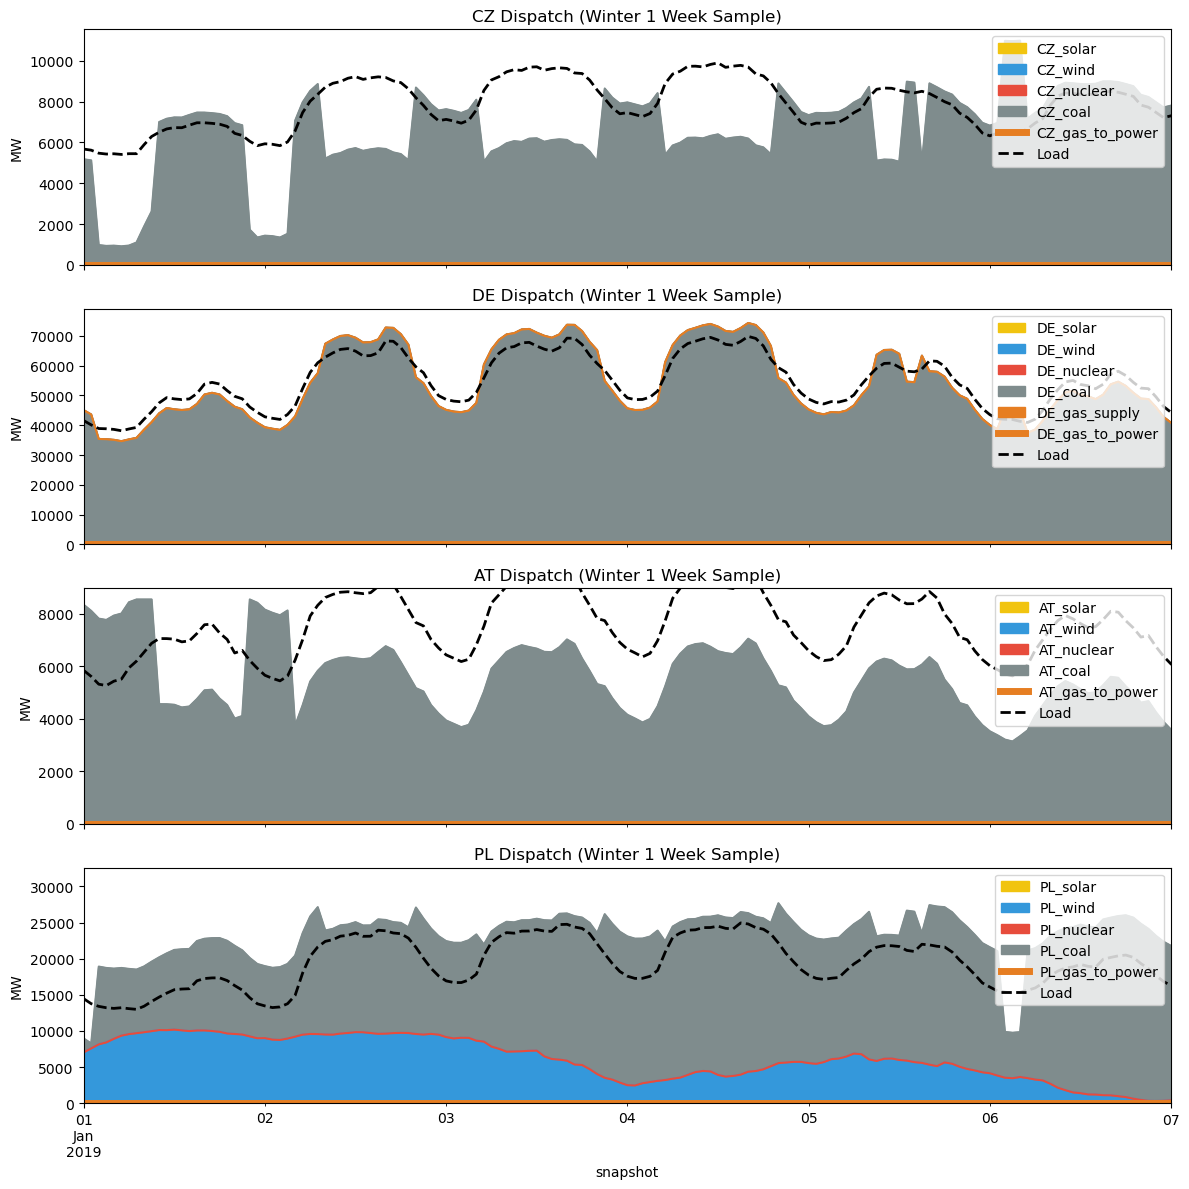

In [ ]:
# --- DISPATCH PLOT (WINTER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):

    ax = axes[i] if len(countries) > 1 else axes

    # -------------------------
    # ELECTRICITY GENERATORS
    # -------------------------
    gens = [g for g in n.generators.index if g.startswith(c)]

    n.generators_t.p[gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in gens],
        alpha=1
    )

    # -------------------------
    # GAS → POWER
    # -------------------------
    gas_links = [l for l in n.links.index if l.startswith(f"{c}_gas_to_power")]

    if len(gas_links) > 0:
        n.links_t.p0[gas_links].plot(
            ax=ax,
            label="Gas to Power",
            linewidth=5,
            color="#e67e22"
        )

    # -------------------------
    # LOAD
    # -------------------------
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

# Shared time window
plt.xlim("2019-01-01", "2019-01-07")

plt.tight_layout()
plt.show()

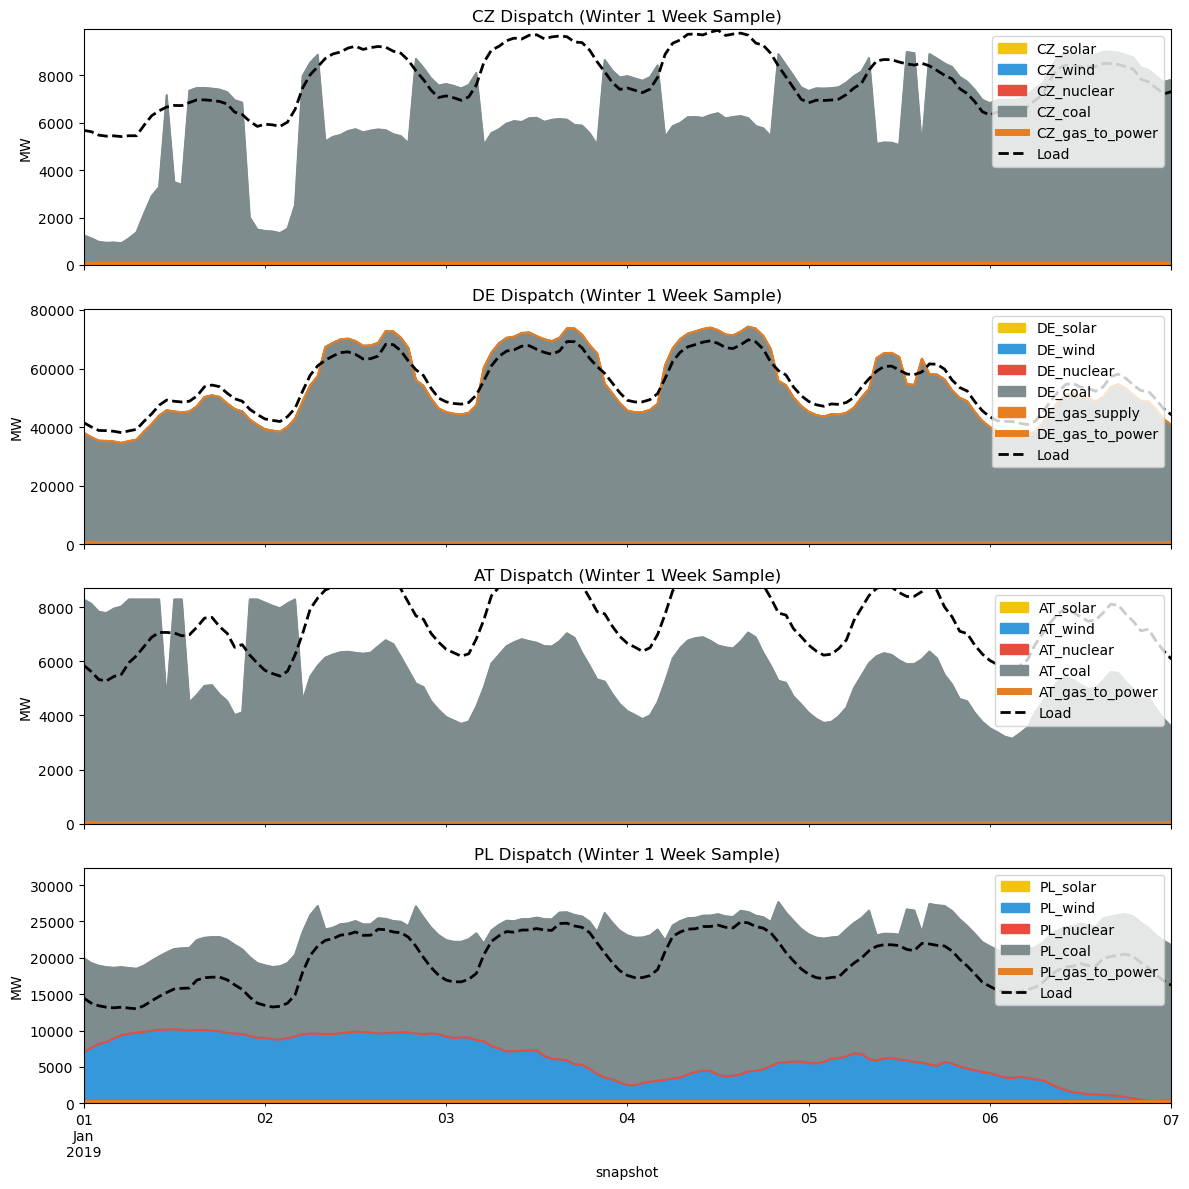

In [ ]:
# --- DISPATCH PLOT (WINTER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):

    ax = axes[i] if len(countries) > 1 else axes

    # -------------------------
    # ELECTRICITY GENERATORS
    # -------------------------
    gens = [g for g in n2.generators.index if g.startswith(c)]

    n2.generators_t.p[gens].plot.area(
        ax=ax,
        color=[n2.carriers.at[n2.generators.at[g, "carrier"], "color"] for g in gens],
        alpha=1
    )

    # -------------------------
    # GAS → POWER
    # -------------------------
    gas_links = [l for l in n2.links.index if l.startswith(f"{c}_gas_to_power")]

    if len(gas_links) > 0:
        n2.links_t.p0[gas_links].plot(
            ax=ax,
            label="Gas to Power",
            linewidth=5,
            color="#e67e22"
        )

    # -------------------------
    # LOAD
    # -------------------------
    n2.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

# Shared time window
plt.xlim("2019-01-01", "2019-01-07")

plt.tight_layout()
plt.show()

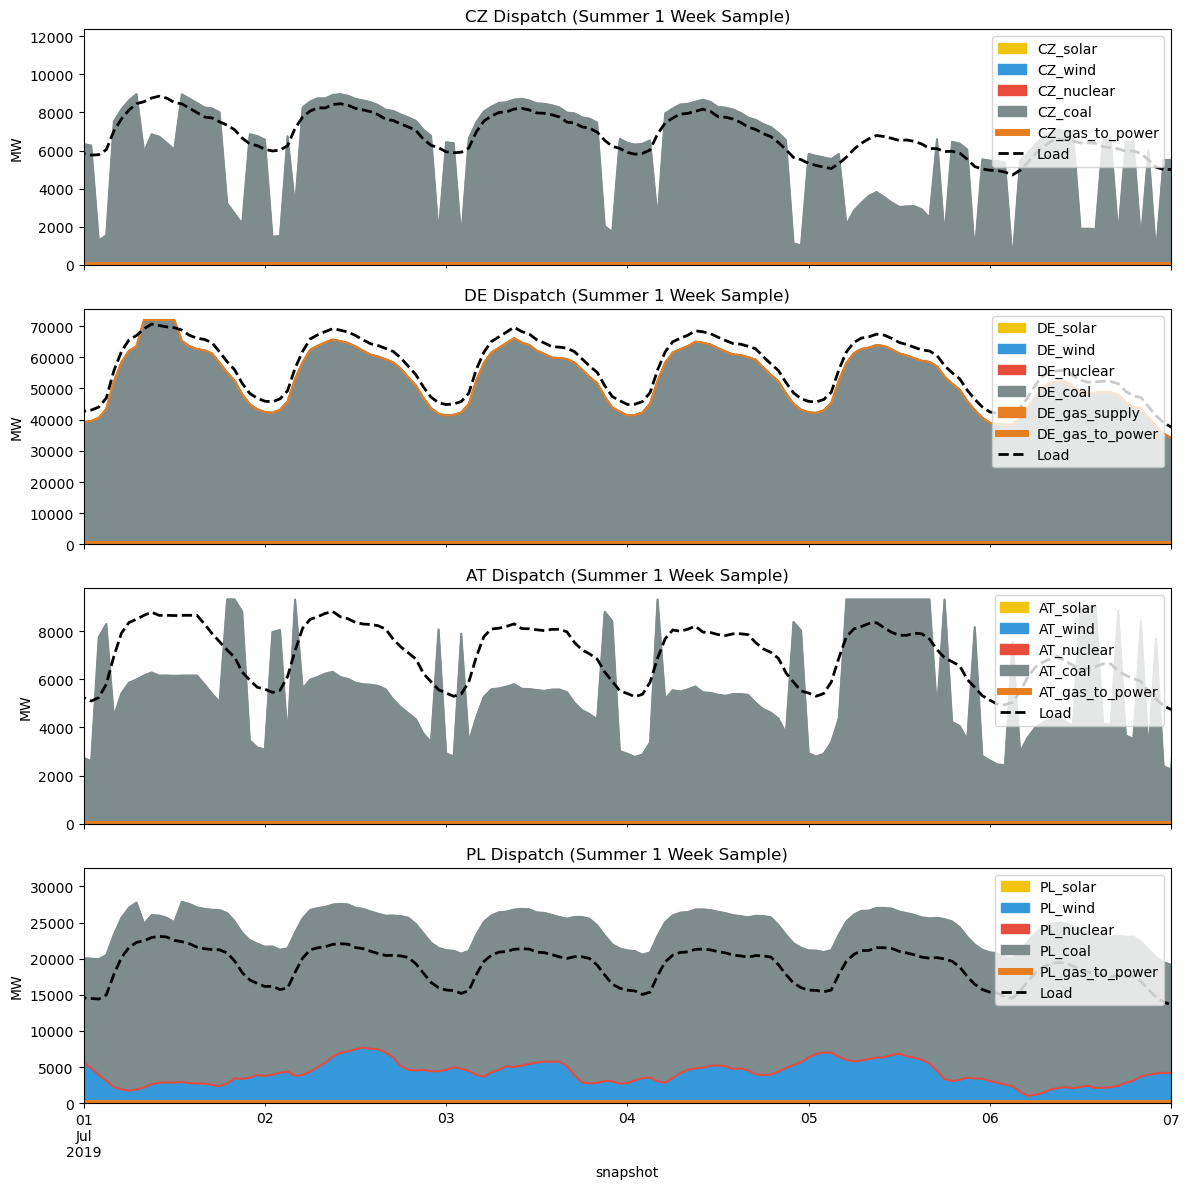

In [ ]:
# --- DISPATCH PLOT (SUMMER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):

    ax = axes[i] if len(countries) > 1 else axes

    # -------------------------
    # ELECTRICITY GENERATORS
    # -------------------------
    gens = [g for g in n.generators.index if g.startswith(c)]

    n.generators_t.p[gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in gens],
        alpha=1
    )

    # -------------------------
    # GAS → POWER
    # -------------------------
    gas_links = [l for l in n.links.index if l.startswith(f"{c}_gas_to_power")]

    if len(gas_links) > 0:
        n.links_t.p0[gas_links].plot(
            ax=ax,
            label="Gas to Power",
            linewidth=5,
            color="#e67e22"
        )

    # -------------------------
    # LOAD
    # -------------------------
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Summer 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

# Shared time window
plt.xlim("2019-07-01", "2019-07-07")

plt.tight_layout()
plt.show()

In [ ]:
elec_flow = n.lines_t.p0.abs().sum().sum()

gas_supply = n.generators_t.p["DE_gas_supply"].sum()

gas_lines = [l for l in n.links.index if "gas_pipe" in l]
gas_flow = n.links_t.p0[gas_lines].abs().sum().sum()

In [ ]:
gas_n = n.links_t.p0[[l for l in n.links.index if "gas_pipe" in l]].abs().sum().sum()
gas_n2 = n2.links_t.p0[[l for l in n2.links.index if "gas_to_power" in l]].abs().sum().sum()

print("Gas transport (network):", gas_n)
print("Gas usage (single bus):", gas_n2)

print("Electricity transport (n):", n.lines_t.p0.abs().sum().sum())
print("Electricity transport (n2):", n2.lines_t.p0.abs().sum().sum())

Gas transport (network): 0.0
Gas usage (single bus): 0.0
Electricity transport (n): 75553242.98051849
Electricity transport (n2): 75564840.99164574


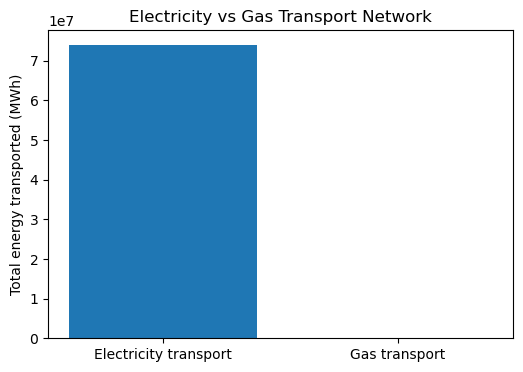

In [ ]:
labels = ["Electricity transport", "Gas transport"]
values = [elec_flow, gas_flow]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.ylabel("Total energy transported (MWh)")
plt.title("Electricity vs Gas Transport Network")

plt.show()